In [1]:
import os
os.getcwd()
import constants

In [2]:
import silmaril
import astropy
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

s = astropy.coordinates.SkyCoord(24.3468342,-8.4645026,unit="deg")
image_plane = silmaril.Grid(s,1000,0.031) # 0.031 arcseconds per pixel, 1000 pixels
wcs = astropy.wcs.WCS(astropy.io.fits.open(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")[0].header)
x_deflections = silmaril.open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")
y_deflections = silmaril.open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_y-arcsec-deflect.fits")

# fits file is the standard for astronomy community for 

# hdul = fits.open(r"C:\\Users\\josep\Documents\\Python Projects\\hlsp_relics_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits")
# hdul.info()

lens = silmaril.Lens(x_deflections,y_deflections,wcs,redshift=0.566,unit='arcsec')

#Line below is characterized by the "detector"
detector = silmaril.Detector(resolution=0.031,fov=30,center=astropy.coordinates.SkyCoord(24.34819561, -8.46520946,unit="deg"),psf_fwhm=2.065)

conv = lens.convergence(image_plane,6.2)
mag_line = lens.magnification_line(image_plane,6.2)

In [3]:
import yt 
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load(constants.SIMULATION_PATH, extra_particle_fields=epf)
ad = ds.all_data() 

yt : [INFO     ] 2026-05-03 21:57:54,914 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-05-03 21:57:54,915 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-05-03 21:57:54,917 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-03 21:57:54,918 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-05-03 21:57:54,920 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-05-03 21:57:54,922 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-05-03 21:57:54,922 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-05-03 21:57:54,923 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-05-03 21:57:54,925 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-05-03 21:57:54,927 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-05-03 21:57:55,138 This output

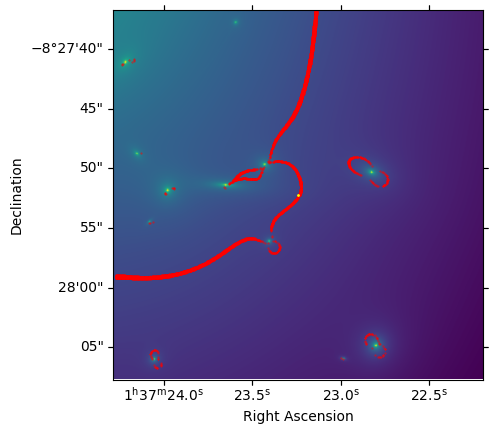

In [4]:
ax = plt.subplot(projection=image_plane.wcs)
ax.imshow(np.log10(abs(conv)),origin="lower")
 # Color shows distribution of mass in the lens plane; start with angles and derive mass per unit area
ax.scatter(mag_line[:,0],mag_line[:,1],s=0.1,color="red",transform=ax.get_transform('world')) #Red line = caustics
ax.scatter(24.3468342,-8.4645026,s=1,color="yellow",transform=ax.get_transform('world')) # Yellow dot on red line is where the image is!
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')


In [5]:
lens.trace_points([[24.3468342,-8.4645026]],6.2)

array([24.35380691, -8.45843597])

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

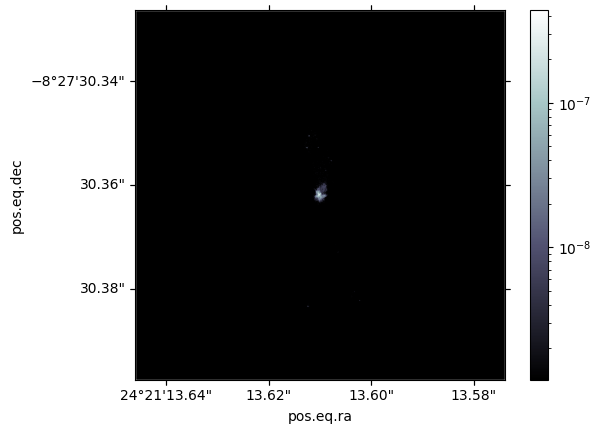

In [8]:
# Line below gives the position of the galaxy--play with this!
galaxy = silmaril.Galaxy("output.txt",redshift=6.2,size=200,center=astropy.coordinates.SkyCoord(24.35378054, -8.45843384,unit="deg")); # loads in the actual galaxy at the source plane
observation = silmaril.Observation(detector,lens,galaxy);

galaxy.plot(1000)

# Image of the galaxy is shown below! (source plane) color = luminosity

In [25]:
# Diagnostic: check source and detector footprints and overlap
try:
    source_res = 800
    src_grid = galaxy.grid(source_res)
    src_xmin, src_xmax = np.min(src_grid.x), np.max(src_grid.x)
    src_ymin, src_ymax = np.min(src_grid.y), np.max(src_grid.y)
    print('g.angular_size (arcsec):', galaxy.angular_size)
    print('source x range (deg):', src_xmin, src_xmax)
    print('source y range (deg):', src_ymin, src_ymax)
    print('galaxy.pixel_scale (arcsec):', galaxy.pixel_scale(source_res))
    # detector grid world coords
    det_grid = detector.grid
    det_coords = det_grid.as_2d_array()  # shape (n,n,2) with ra,dec in deg
    det_ra_min, det_ra_max = det_coords[:,:,0].min(), det_coords[:,:,0].max()
    det_dec_min, det_dec_max = det_coords[:,:,1].min(), det_coords[:,:,1].max()
    print('detector RA range (deg):', det_ra_min, det_ra_max)
    print('detector DEC range (deg):', det_dec_min, det_dec_max)
    # simple bbox overlap in sky coords
    bbox_overlap = not (src_xmax < det_ra_min or src_xmin > det_ra_max or src_ymax < det_dec_min or src_ymin > det_dec_max)
    print('bbox overlap (deg):', bbox_overlap)
    # Ray-trace detector grid back to source plane and count overlaps
    traced_x, traced_y = lens.trace_grid(detector.grid, galaxy.redshift)
    n_inside = np.count_nonzero((traced_x >= src_xmin) & (traced_x <= src_xmax) & (traced_y >= src_ymin) & (traced_y <= src_ymax))
    print('number of traced detector pixels whose traced positions fall inside source plane range:', n_inside)
except Exception as e:
    print('Diagnostic failed:', e)

g.angular_size (arcsec): 0.03561393604860736
source x range (deg): 24.353770659605935 24.353790420394063
source y range (deg): -8.458443720394063 -8.458423959605936
galaxy.pixel_scale (arcsec): 8.90348401215184e-05
detector RA range (deg): 24.344036443333337 24.352354776666665
detector DEC range (deg): -8.469368626666668 -8.461050293333333
bbox overlap (deg): False
number of traced detector pixels whose traced positions fall inside source plane range: 1241


[0. 0. 0. ... 0. 0. 0.]
[0.00000000e+00 1.57203115e-13 2.06857733e-13 2.18628517e-13
 2.34779100e-13 2.52819307e-13 3.09962375e-13 3.10570919e-13
 3.56999582e-13 3.64466585e-13 4.13798200e-13 4.20564843e-13
 4.27888278e-13 4.31438050e-13 4.43835489e-13 4.73614539e-13
 5.27970236e-13 5.31441710e-13 5.33218104e-13 5.48378470e-13
 5.81854986e-13 5.94399234e-13 5.97564167e-13 6.09755050e-13
 6.14732800e-13 6.21102191e-13 7.02766765e-13 7.06036918e-13
 7.09244808e-13 7.17384988e-13 8.19716983e-13 8.23981465e-13
 8.26006487e-13 8.70356560e-13 8.72150246e-13 8.94308188e-13
 8.98849154e-13 9.61004897e-13 9.85578664e-13 1.08690531e-12
 1.09432607e-12 1.16291482e-12 1.25335105e-12 1.39287065e-12
 1.41293071e-12 1.42826840e-12 1.42963275e-12 1.45145870e-12
 1.53013814e-12 1.54813205e-12 1.57201348e-12 1.60131695e-12
 1.69363761e-12 1.76261310e-12 1.77129864e-12 1.82151963e-12
 1.82900915e-12 1.83408048e-12 1.87494601e-12 1.91426304e-12
 2.17678316e-12 2.20559956e-12 2.22748084e-12 2.29830215e-12


(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

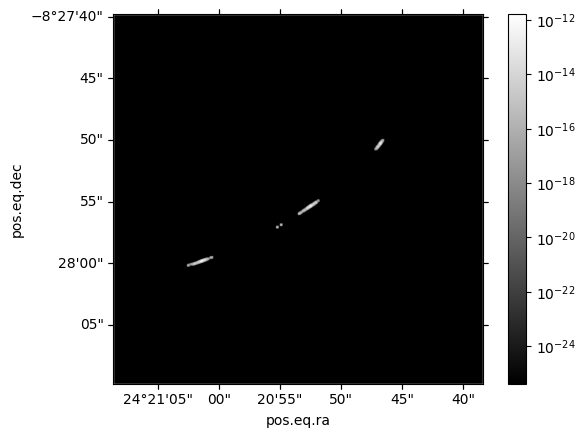

In [10]:
galaxy.pixel_scale(resolution=1000,zoom_factor=1)

lensed_image = observation.simulate_observation(background=3e-11,noise=5e-12,source_resolution=1000,star_by_star=True, filter_name="F200W")
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=False, filter_name="F277W")

# Actual lensed image simulation

In [17]:
nonempty_pixels, _, _, luminosities = observation.trace_pixels(800, filter_name="F200W", star_by_star=True)
luminosities.shape, len(nonempty_pixels)

[0. 0. 0. ... 0. 0. 0.]
[0.00000000e+00 1.57203115e-13 2.06857733e-13 2.18628517e-13
 2.34779100e-13 2.52819307e-13 3.09962375e-13 3.10570919e-13
 3.56999582e-13 3.64466585e-13 4.13798200e-13 4.20564843e-13
 4.27888278e-13 4.31438050e-13 4.43835489e-13 4.73614539e-13
 5.27970236e-13 5.31441710e-13 5.33218104e-13 5.48378470e-13
 5.81854986e-13 5.94399234e-13 5.97564167e-13 6.09755050e-13
 6.14732800e-13 6.21102191e-13 7.02766765e-13 7.06036918e-13
 7.09244808e-13 7.17384988e-13 8.19716983e-13 8.23981465e-13
 8.26006487e-13 8.70356560e-13 8.72150246e-13 8.94308188e-13
 8.98849154e-13 9.61004897e-13 9.85578664e-13 1.08690531e-12
 1.09432607e-12 1.16291482e-12 1.25335105e-12 1.39287065e-12
 1.41293071e-12 1.42826840e-12 1.42963275e-12 1.45145870e-12
 1.53013814e-12 1.54813205e-12 1.57201348e-12 1.60131695e-12
 1.69363761e-12 1.76261310e-12 1.77129864e-12 1.82151963e-12
 1.82900915e-12 1.83408048e-12 1.87494601e-12 1.91426304e-12
 2.17678316e-12 2.20559956e-12 2.22748084e-12 2.29830215e-12


((1235,), 1235)

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

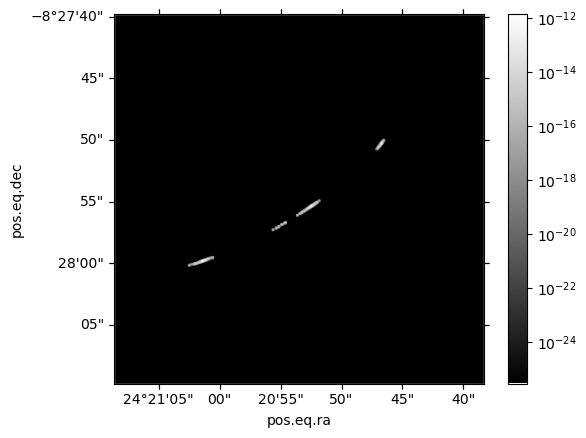

In [ ]:
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=True,filter_name="F277W")

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

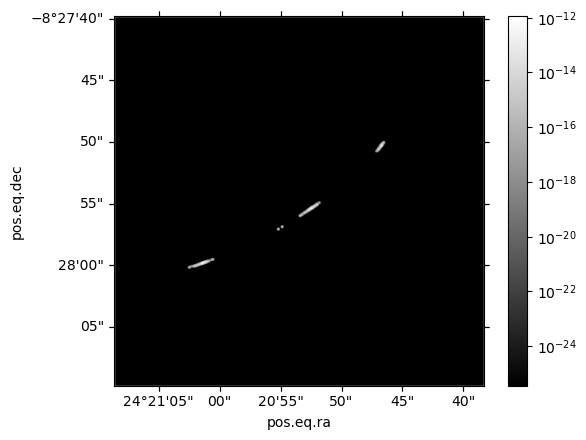

In [ ]:
observation.plot(background=0,noise=0,source_resolution=1000,filter_name="F070W")

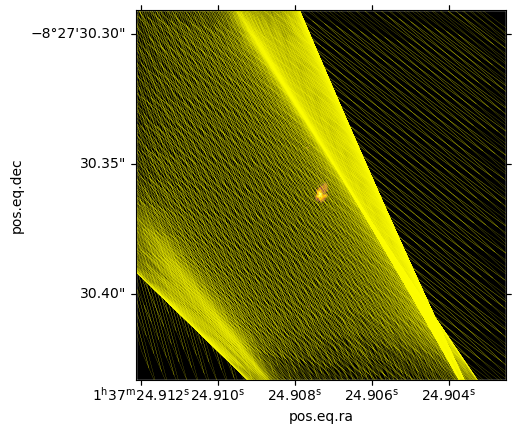

In [ ]:

from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib.colors import LogNorm
nonempty_pixels, arc_pixels, polygons, luminosities = observation.trace_pixels(source_resolution=1000,zoom_factor=2)

ax = plt.subplot(projection=galaxy.grid(1000,2).wcs)
ax.imshow(galaxy.create_image(resolution=1000,zoom_factor=2),norm=LogNorm(1e-9,1e-7),cmap="inferno")
polygons = [Polygon(p,closed=True,fill=False,color="yellow",lw=0.1,transform=ax.get_transform('world')) for p in polygons]

ax.set_facecolor('black')
for i,p in enumerate(polygons):
    ax.add_patch(p)

    #Image shows grid overlayed on the galaxy (lines are actually elongated grids)